In [1]:
# LightGBM Regression for RR Prediction
# Optimized with Hyperparameter Tuning
# Subject-wise CV + Feature Importance

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor


In [2]:
# ---------------------------
# Step 1: Load Features
# ---------------------------
features_df = pd.read_csv(r"C:\Users\admin\OneDrive\Desktop\healthcare_ppg\data\processed\features_rr.csv")

# Optional: Drop low-importance features
features_to_drop = ['kurtosis', 'mean', 'std', 'rms']
features_df = features_df.drop(columns=features_to_drop)

# Define X and y
X = features_df.drop("RR", axis=1).values
y = features_df["RR"].values

# Rebuild subject IDs
num_subjects = 53
windows_per_subject = X.shape[0] // num_subjects
subjects = np.repeat(np.arange(num_subjects), windows_per_subject)
remaining = X.shape[0] - subjects.shape[0]
subjects = np.concatenate([subjects, np.arange(remaining)])

print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print("Subjects shape:", subjects.shape)


Features shape: (1638, 8)
Labels shape: (1638,)
Subjects shape: (1638,)


In [3]:

# ---------------------------
# Step 2: Define Pipeline
# ---------------------------
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", lgb.LGBMRegressor(n_estimators=500, random_state=42))
])

# ---------------------------
# Step 3: Define Hyperparameter Grid
# ---------------------------
param_grid = {
    "model__max_depth": [6, 8, 10],
    "model__num_leaves": [20, 30, 40],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

# ---------------------------
# Step 4: Setup Group-wise CV
# ---------------------------
gkf = GroupKFold(n_splits=5)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# ---------------------------
# Step 5: Run GridSearchCV
# ---------------------------
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=gkf.split(X, y, groups=subjects),
    scoring=mae_scorer,
    n_jobs=-1,
    verbose=2
)

grid.fit(X, y)

# ---------------------------
# Step 6: Best Parameters & MAE
# ---------------------------
print("Best parameters:", grid.best_params_)
print("Best MAE (negative):", grid.best_score_)
print("Expected MAE (positive):", -grid.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1638, number of used features: 8
[LightGBM] [Info] Start training from score 17.347375
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [7]:
#  Feature Importance
best_pipeline = grid.best_estimator_
best_pipeline.fit(X, y)
y_pred = best_pipeline.predict(X)
errors = y_pred - y

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000455 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1638, number of used features: 8
[LightGBM] [Info] Start training from score 17.347375
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


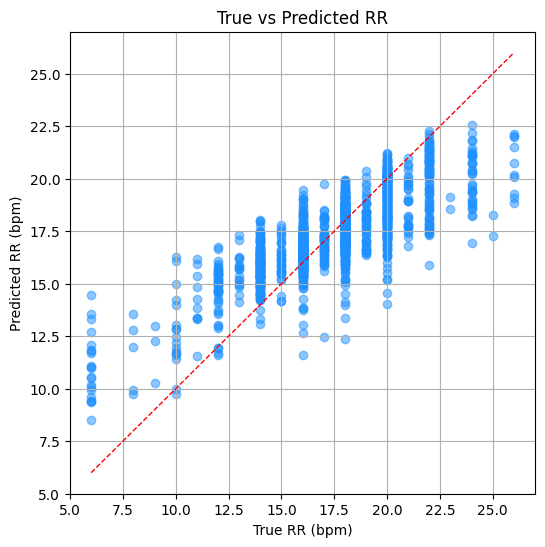

In [13]:

# True vs Predicted Scatter
# ---------------------------
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.5, color='dodgerblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=1)
plt.xlabel("True RR (bpm)")
plt.ylabel("Predicted RR (bpm)")
plt.title("True vs Predicted RR")
plt.grid(True)
plt.show()


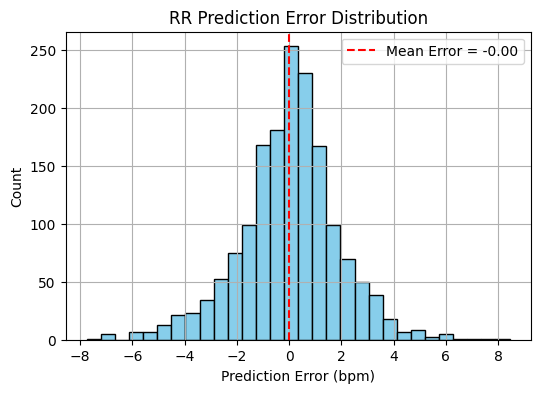

In [9]:

# Prediction Error Histogram
# ---------------------------
plt.figure(figsize=(6,4))
plt.hist(errors, bins=30, color='skyblue', edgecolor='k')
plt.axvline(errors.mean(), color='red', linestyle='--', label=f"Mean Error = {errors.mean():.2f}")
plt.xlabel("Prediction Error (bpm)")
plt.ylabel("Count")
plt.title("RR Prediction Error Distribution")
plt.legend()
plt.grid(True)
plt.show()


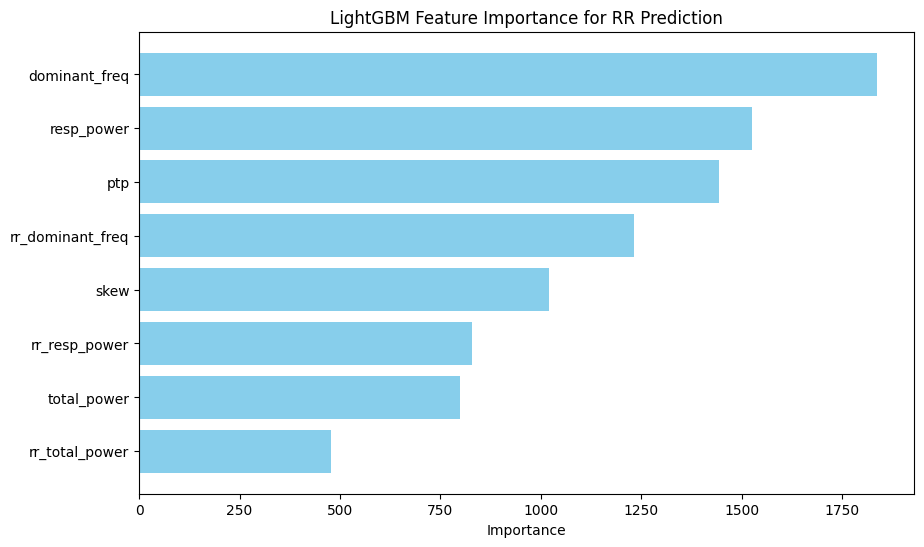

In [10]:

# Feature Importance (Horizontal Bar)
# ---------------------------
feature_names = features_df.drop("RR", axis=1).columns
importances = best_pipeline.named_steps['model'].feature_importances_
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'], color='skyblue')
plt.xlabel("Importance")
plt.title("LightGBM Feature Importance for RR Prediction")
plt.show()


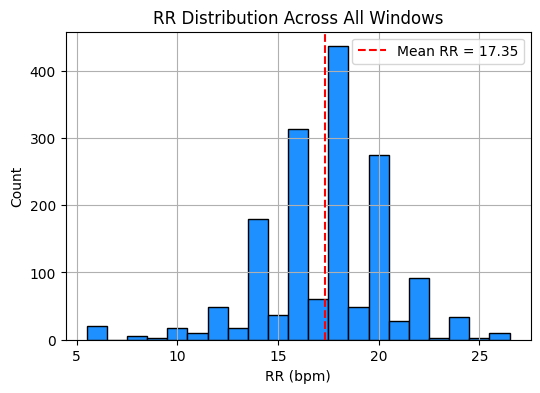

In [11]:

# RR Distribution Histogram
# ---------------------------
plt.figure(figsize=(6,4))
plt.hist(y, bins=np.arange(y.min()-0.5, y.max()+1.5, 1), color='dodgerblue', edgecolor='k')
plt.xlabel("RR (bpm)")
plt.ylabel("Count")
plt.title("RR Distribution Across All Windows")
plt.axvline(y.mean(), color='red', linestyle='--', label=f"Mean RR = {y.mean():.2f}")
plt.legend()
plt.grid(True)
plt.show()

In [21]:

# Subject-wise CV MAE with Best Model
# ---------------------------
mae_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=subjects)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    best_pipeline.fit(X_train, y_train)
    y_pred = best_pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores.append(mae)
    print(f"Fold {fold+1} MAE: {mae:.3f} bpm")



# Retrain Best Model on Full Data
# ---------------------------
best_pipeline = grid.best_estimator_
best_pipeline.fit(X, y)

print("\nMean MAE:", np.mean(mae_scores))
print("Std MAE:", np.std(mae_scores))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1298, number of used features: 8
[LightGBM] [Info] Start training from score 17.446071
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

Fold 3 MAE: 1.771 bpm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1299, number of used features: 8
[LightGBM] [Info] Start training from score 17.417244
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 4 MAE: 2.043 bpm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000291 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1299, number of used features: 8
[LightGBM] [Info] Start training from score 16.977675
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

C:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 5 MAE: 2.125 bpm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000337 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1638, number of used features: 8
[LightGBM] [Info] Start training from score 17.347375
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

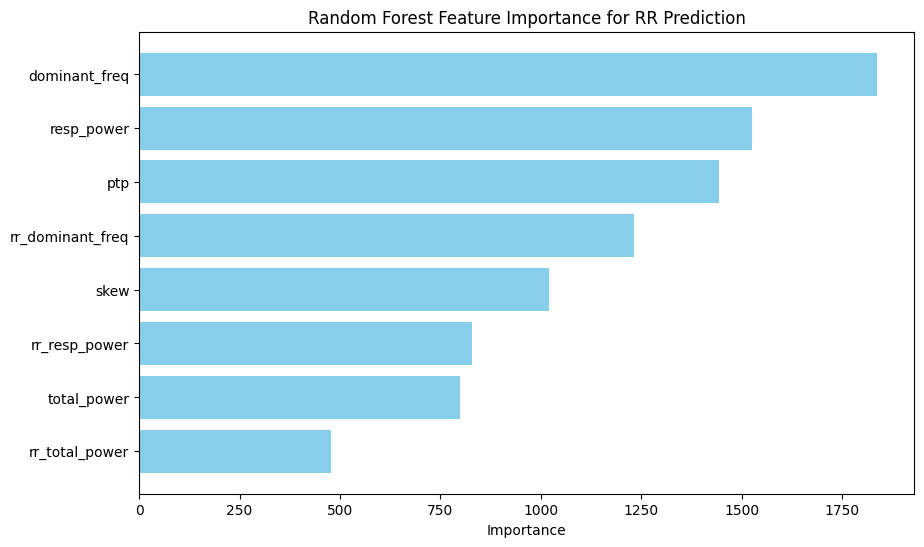

In [22]:
# ---------------------------
# Step 8: Feature Importance
# ---------------------------
feature_names = features_df.drop("RR", axis=1).columns
importances = best_pipeline.named_steps['model'].feature_importances_

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=True)

# Horizontal bar plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'], color='skyblue')
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance for RR Prediction")
plt.show()

In [23]:
import os
import joblib

# ---------------------------
# Saving the trained pipeline
# ---------------------------

model_folder = r"C:\Users\admin\OneDrive\Desktop\healthcare_ppg\models"

if not os.path.exists(model_folder):
    os.makedirs(model_folder)
    print(f"Folder created: {model_folder}")
else:
    print(f"Folder already exists: {model_folder}")

model_path = os.path.join(model_folder, "best_lgbm_rr_pipeline.pkl")
joblib.dump(best_pipeline, model_path)

print(f"Model saved successfully at: {model_path}")

Folder created: C:\Users\admin\OneDrive\Desktop\healthcare_ppg\models
Model saved successfully at: C:\Users\admin\OneDrive\Desktop\healthcare_ppg\models\best_lgbm_rr_pipeline.pkl
